In [1]:
from ultralytics import YOLO
import numpy as np
import pandas as pd
import os, cv2
import yaml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBClassifier


In [2]:
pose_model = YOLO("yolov8n-pose.pt")

In [3]:
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_angles(kp):
    def safe_angle(ia, ib, ic):
        a, b, c = kp[ia], kp[ib], kp[ic]
        if np.all(a==0) or np.all(b==0) or np.all(c==0):
            return -1
        return calculate_angle(a, b, c)

    def safe_dist(ia, ib):
        a, b = kp[ia], kp[ib]
        if np.all(a==0) or np.all(b==0):
            return -1
        return float(np.linalg.norm(a - b))
    
    sh_w = safe_dist(5, 6)
    norm = sh_w if sh_w > 0 else 1.0

    def norm_y(ia, ib):
        if np.all(kp[ia]==0) or np.all(kp[ib]==0):
            return -1
        return float((kp[ia][1] - kp[ib][1]) / norm)

    def norm_x(ia, ib):
        if np.all(kp[ia]==0) or np.all(kp[ib]==0):
            return -1
        return float((kp[ia][0] - kp[ib][0]) / norm)

    return {
        #head n shoulder angles buat liat kalo misal muridnya lagi fokus atau tidak (shoulder n neck angles upward or downward)
        "neck_tilt":           safe_angle(0,  5,  6),
        "head_spine_l":        safe_angle(0,  5,  11),
        "head_spine_r":        safe_angle(0,  6,  12),
        "spine_l":             safe_angle(5,  11, 13),
        "spine_r":             safe_angle(6,  12, 14),
        "shoulder_tilt":       safe_angle(11, 5,  6),

        #arm angles buat menghitung setinggi apa atau serendah apa tangan murid di angkat untuk class "raised hand"
        "left_elbow":          safe_angle(5,  7,  9),
        "right_elbow":         safe_angle(6,  8,  10),
        "left_shoulder_ang":   safe_angle(11, 5,  7),
        "right_shoulder_ang":  safe_angle(12, 6,  8),

        #vertical position feature, feature utama untuk menentukan pose siswa/siswa misal untuk feature nose_shoulder_y 
        # jika valuenya negative artinya nose lebih tinggi dari shoulder dan posenya merupakan look up
        "nose_shoulder_y":     norm_y(0,  5),
        "nose_hip_y":          norm_y(0,  11),
        "ear_shoulder_y_l":    norm_y(3,  5),
        "ear_shoulder_y_r":    norm_y(4,  6),
        "wrist_shoulder_y_l":  norm_y(9,  5),
        "wrist_shoulder_y_r":  norm_y(10, 6),
        "elbow_shoulder_y_l":  norm_y(7,  5),
        "elbow_shoulder_y_r":  norm_y(8,  6),

        #horizontal  position seperti vertical position feature-feature ini diggunakan untuk melihat apakah keypoint dari siswa/siswi 
        # biasanya untuk class seperti turn_head atau distracted karena kepala murid tidak menghadap kedepan
        "nose_center_x":       norm_x(0,  5),
        "ear_asymmetry_x":     norm_x(3,  4),
        "eye_asymmetry_x":     norm_x(1,  2),   
        "nose_hip_x":          norm_x(0,  11),  

        #distance feature ini untuk melihat jarak antar 2 keypoints kenapa tidak angle? soalnya misal jarak antar shoulder ke hip itu akan 
        # berubah tergantung dengan pose muridnya kalo misal sedang berdiri jaraknya akan sangat jauh dan ketika duduk akan lebih kecil dan 
        # ketika bow akan lebih kecil lagi dan hal tersebut tidak dapat di capture oleh angle.
        "shoulder_hip_dist":   safe_dist(5,  11),
        "nose_shoulder_dist":  safe_dist(0,  5),
        "wrist_hip_l":         safe_dist(9,  11),
        "wrist_hip_r":         safe_dist(10, 12),
        "wrist_height_diff":   norm_y(9,  10),
        "elbow_height_diff":   norm_y(7,  8),
        
        #Lower body features feature-feature ini untuk menentukan apakah murid sedang duduk atau berdiri
        "hip_y_abs":           norm_y(11, 5),  
        "knee_y_abs":          norm_y(13, 5),   
        "ankle_y_abs":         norm_y(15, 5),   

    }

In [4]:
def get_behavior_label(label_path, img_w, img_h, class_names):
    if not os.path.exists(label_path):
        return None
    with open(label_path) as f:
        lines = f.readlines()
    if not lines:
        return None

    class_id = int(lines[0].split()[0])
    return class_names[class_id]


In [5]:
def process_dataset(split_dir, class_names, output_csv):
    img_dir = f"{split_dir}/images"
    lbl_dir = f"{split_dir}/labels"
    
    rows = []
    
    for img_file in os.listdir(img_dir):
        if not img_file.endswith((".jpg", ".png", ".jpeg")):
            continue
        
        img_path  = f"{img_dir}/{img_file}"
        lbl_path  = f"{lbl_dir}/{os.path.splitext(img_file)[0]}.txt"
        
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        behavior = get_behavior_label(lbl_path, w, h, class_names)
        if behavior is None:
            continue
        
       
        results = pose_model(img_path, verbose=False)
        
        for result in results:
            if result.keypoints is None:
                continue
            
            kps = result.keypoints.xy.cpu().numpy()
            
            for kp in kps:
                angles = extract_angles(kp)
                angles["label"] = behavior
                rows.append(angles)
    
    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    return df

In [6]:
with open(f"student behavior.v15i.yolov8/data.yaml") as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

df_train = process_dataset(f"student behavior.v15i.yolov8/train", class_names, "features_train.csv")
df_val = process_dataset(f"student behavior.v15i.yolov8/valid", class_names, "features_val.csv")
df_all = pd.concat([df_train, df_val], ignore_index=True)
df_all.to_csv("Dataset2_features.csv", index=False)

In [7]:
df = pd.read_csv("Dataset2_features.csv")
df = df.replace(-1, np.nan).dropna()

In [8]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [9]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

         bow       0.24      0.23      0.23       158
        down       0.81      0.82      0.81      2835
      lookup       0.89      0.84      0.87      1899
         sit       0.68      0.73      0.70      1141

    accuracy                           0.79      6033
   macro avg       0.65      0.66      0.65      6033
weighted avg       0.80      0.79      0.79      6033



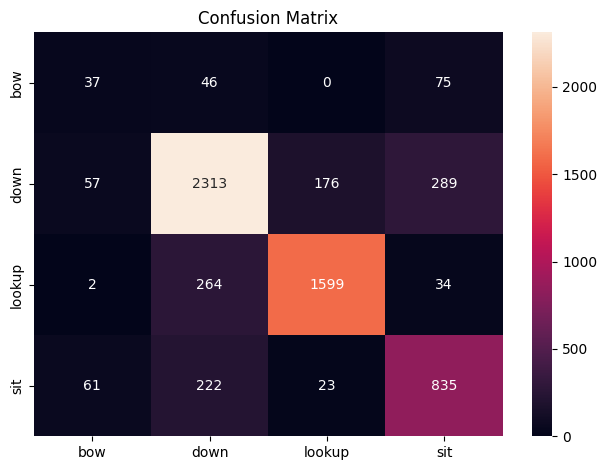

In [11]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(rf, "random_forest_classifier2.pkl")
joblib.dump(le, "label_encoder2.pkl")

['label_encoder2.pkl']